# Vectorization

Prepare a controlled comparison of scalar and vectorized CPU computation.

## Objectives

Distinguish algorithmic, interpreter, and hardware-vectorization effects in array-oriented work.

## Background

Vectorized libraries can move loops into compiled kernels and may use SIMD instructions, reducing interpreter overhead and increasing data parallelism.

## Prediction

A Python element-by-element loop should be much slower than an equivalent NumPy operation because every iteration executes Python bytecode and manipulates Python objects. NumPy should become increasingly advantageous as the array grows because its loop executes in compiled code over contiguous numeric storage. For very small arrays, fixed function-call and array-allocation overhead may dominate, reducing or even eliminating the apparent advantage. A compiled scalar C loop should be much faster than Python but slower than a SIMD-vectorized C loop when computation throughput is the limiting factor. For sufficiently large arrays, both compiled implementations may converge as memory bandwidth becomes the bottleneck.

## Environment

In [1]:
import os
import platform
import socket
import sys
from pathlib import Path

repository_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").is_file()
    ),
    None,
)
if repository_root is None:
    raise RuntimeError("Run this notebook from within the repository")
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Hostname: {socket.gethostname()}")
print(f"Working directory: {os.getcwd()}")

Python: 3.14.3 (main, Feb 12 2026, 00:45:04) [Clang 21.1.4 ]
Platform: Linux-6.17.0-1026-nvidia-aarch64-with-glibc2.39
Hostname: spark-0240
Working directory: /home/coert/workspace/dgx-spark-lab/experiments/00-foundations


## Experiment

In [ ]:
import numpy as np

# TODO: Implement equivalent scalar and NumPy operations with correctness checks.
sample = np.arange(8, dtype=np.float64)
print(sample)

In [2]:
import os
import platform
import subprocess

import numpy as np
import pandas as pd

from common.benchmark import benchmark_callable


print(f"NumPy: {np.__version__}")
print(f"Page size: {os.sysconf('SC_PAGE_SIZE')} bytes")
print(f"Available CPUs: {sorted(os.sched_getaffinity(0))}")

np.show_config()

NumPy: 2.5.1
Page size: 4096 bytes
Available CPUs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Build Dependencies:
  blas:
    detection method: pkgconfig
    found: true
    include directory: /opt/_internal/cpython-3.14.3/lib/python3.14/site-packages/scipy_openblas64/include
    lib directory: /opt/_internal/cpython-3.14.3/lib/python3.14/site-packages/scipy_openblas64/lib
    name: scipy-openblas
    openblas configuration: OpenBLAS 0.3.33.112.0  USE64BITINT DYNAMIC_ARCH NO_AFFINITY
      neoversev2 MAX_THREADS=64
    pc file directory: /project/.openblas
    version: 0.3.33.112.0
  lapack:
    detection method: pkgconfig
    found: true
    include directory: /opt/_internal/cpython-3.14.3/lib/python3.14/site-packages/scipy_openblas64/include
    lib directory: /opt/_internal/cpython-3.14.3/lib/python3.14/site-packages/scipy_openblas64/lib
    name: scipy-openblas
    openblas configuration: OpenBLAS 0.3.33.112.0  USE64BITINT DYNAMIC_ARCH NO_AFFINITY
      

In [3]:
from contextlib import contextmanager


VECTOR_CPU = 15


@contextmanager
def pinned_to_cpu(cpu_id: int):
    original_affinity = os.sched_getaffinity(0)

    try:
        os.sched_setaffinity(0, {cpu_id})
        yield
    finally:
        os.sched_setaffinity(0, original_affinity)


with pinned_to_cpu(VECTOR_CPU):
    print(f"Temporary affinity: {sorted(os.sched_getaffinity(0))}")

Temporary affinity: [15]


In [4]:
SCALE = 1.000_001
OFFSET = 0.125


def python_multiply_add(
    values: list[float],
    scale: float,
    offset: float,
) -> list[float]:
    result = [0.0] * len(values)

    for index in range(len(values)):
        result[index] = values[index] * scale + offset

    return result


def numpy_multiply_add(
    values: np.ndarray,
    scale: float,
    offset: float,
) -> np.ndarray:
    return values * scale + offset

In [5]:
sample_numpy = np.linspace(
    0.0,
    1.0,
    16,
    dtype=np.float64,
)

sample_python = sample_numpy.tolist()

python_result = python_multiply_add(
    sample_python,
    SCALE,
    OFFSET,
)

numpy_result = numpy_multiply_add(
    sample_numpy,
    SCALE,
    OFFSET,
)

np.testing.assert_allclose(
    python_result,
    numpy_result,
    rtol=1e-14,
    atol=1e-14,
)

pd.DataFrame(
    {
        "input": sample_numpy,
        "python": python_result,
        "numpy": numpy_result,
    }
)

,input,python,numpy
0,0.000000,0.125000,0.125000
1,0.066667,0.191667,0.191667
2,0.133333,0.258333,0.258333
3,0.200000,0.325000,0.325000
4,0.266667,0.391667,0.391667
5,0.333333,0.458334,0.458334
6,0.400000,0.525000,0.525000
7,0.466667,0.591667,0.591667
8,0.533333,0.658334,0.658334
9,0.600000,0.725001,0.725001


In [6]:
def numpy_multiply_add_into(
    values: np.ndarray,
    output: np.ndarray,
    scale: float,
    offset: float,
) -> np.ndarray:
    np.multiply(
        values,
        scale,
        out=output,
    )

    np.add(
        output,
        offset,
        out=output,
    )

    return output

In [7]:
sample_output = np.empty_like(sample_numpy)

numpy_into_result = numpy_multiply_add_into(
    sample_numpy,
    sample_output,
    SCALE,
    OFFSET,
)

np.testing.assert_allclose(
    python_result,
    numpy_into_result,
    rtol=1e-14,
    atol=1e-14,
)

In [ ]:
ELEMENT_COUNTS = [
    16,
    64,
    256,
    1_024,
    4_096,
    16_384,
    65_536,
    262_144,
    1_048_576,
]

BENCHMARK_ITERATIONS = 10
WARMUP_ITERATIONS = 3

vectorization_rows = []

for element_count in ELEMENT_COUNTS:
    numpy_values = np.linspace(
        0.0,
        1.0,
        element_count,
        dtype=np.float64,
    )

    python_values = numpy_values.tolist()
    numpy_output = np.empty_like(numpy_values)

    with pinned_to_cpu(VECTOR_CPU):
        python_timing = benchmark_callable(
            python_multiply_add,
            python_values,
            SCALE,
            OFFSET,
            warmup_iterations=WARMUP_ITERATIONS,
            iterations=BENCHMARK_ITERATIONS,
        )

        numpy_timing = benchmark_callable(
            numpy_multiply_add,
            numpy_values,
            SCALE,
            OFFSET,
            warmup_iterations=WARMUP_ITERATIONS,
            iterations=BENCHMARK_ITERATIONS,
        )

        numpy_into_timing = benchmark_callable(
            numpy_multiply_add_into,
            numpy_values,
            numpy_output,
            SCALE,
            OFFSET,
            warmup_iterations=WARMUP_ITERATIONS,
            iterations=BENCHMARK_ITERATIONS,
        )

    for implementation, timing in [
        ("Python loop", python_timing),
        ("NumPy allocating", numpy_timing),
        ("NumPy preallocated", numpy_into_timing),
    ]:
        vectorization_rows.append(
            {
                "element_count": element_count,
                "data_mib": element_count * 8 / 1024**2,
                "implementation": implementation,
                "minimum_ms": timing.minimum_ns / 1e6,
                "median_ms": timing.median_ns / 1e6,
                "mean_ms": timing.mean_ns / 1e6,
                "standard_deviation_ms": (timing.standard_deviation_ns / 1e6),
                "nanoseconds_per_element": (timing.median_ns / element_count),
            }
        )

vectorization_results = pd.DataFrame(vectorization_rows)

vectorization_results

,element_count,data_mib,implementation,minimum_ms,median_ms,mean_ms,standard_deviation_ms,nanoseconds_per_element
0,16,0.000122,Python loop,0.000464,0.000480,0.000664,0.000403,30.000000
1,16,0.000122,NumPy allocating,0.000544,0.000568,0.000590,0.000065,35.500000
2,16,0.000122,NumPy preallocated,0.000544,0.000576,0.000594,0.000044,36.000000
3,64,0.000488,Python loop,0.001440,0.001472,0.001474,0.000025,23.000000
4,64,0.000488,NumPy allocating,0.000576,0.000592,0.000602,0.000026,9.250000
5,64,0.000488,NumPy preallocated,0.000560,0.000592,0.000603,0.000030,9.250000
6,256,0.001953,Python loop,0.005952,0.006016,0.006552,0.001614,23.500000
7,256,0.001953,NumPy allocating,0.000640,0.000672,0.000691,0.000044,2.625000
8,256,0.001953,NumPy preallocated,0.000608,0.000648,0.000650,0.000025,2.531250
9,1024,0.007812,Python loop,0.026320,0.026664,0.026619,0.000217,26.039062


In [ ]:
timing_pivot = vectorization_results.pivot(
    index=["element_count", "data_mib"],
    columns="implementation",
    values="median_ms",
).reset_index()

timing_pivot["numpy_allocating_speedup"] = (
    timing_pivot["Python loop"] / timing_pivot["NumPy allocating"]
)

timing_pivot["numpy_preallocated_speedup"] = (
    timing_pivot["Python loop"] / timing_pivot["NumPy preallocated"]
)

timing_pivot

implementation,element_count,data_mib,NumPy allocating,NumPy preallocated,Python loop,numpy_allocating_speedup,numpy_preallocated_speedup
0,16,0.000122,0.000568,0.000576,0.000480,0.845070,0.833333
1,64,0.000488,0.000592,0.000592,0.001472,2.486486,2.486486
2,256,0.001953,0.000672,0.000648,0.006016,8.952381,9.283951
3,1024,0.007812,0.000920,0.000848,0.026664,28.982609,31.443396
4,4096,0.031250,0.001464,0.001448,0.106400,72.677596,73.480663
5,16384,0.125000,0.003232,0.003616,0.428241,132.500309,118.429480
6,65536,0.500000,0.013720,0.011640,1.736413,126.560714,149.176375
7,262144,2.000000,0.067681,0.055440,9.154433,135.259543,165.121770
8,1048576,8.000000,0.352953,0.307929,41.608244,117.886074,135.122848


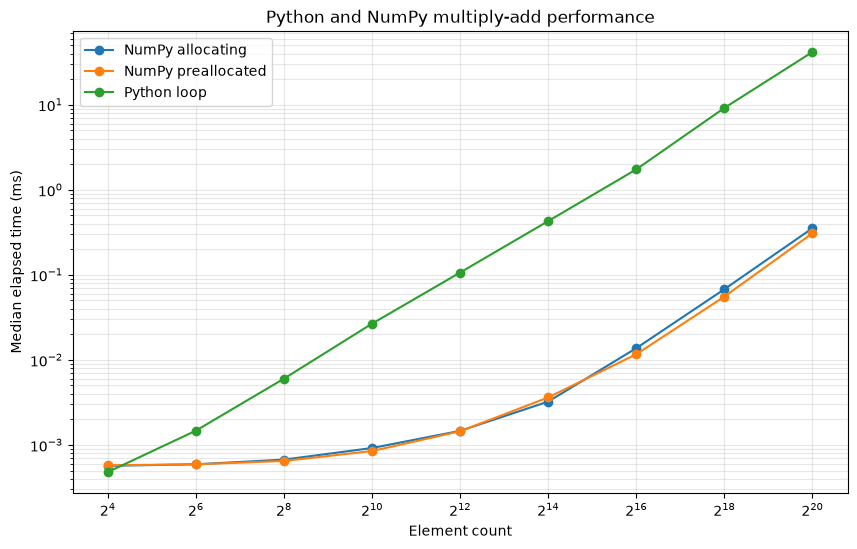

In [ ]:
import matplotlib.pyplot as plt


figure, axis = plt.subplots(figsize=(10, 6))

for implementation, results in vectorization_results.groupby("implementation"):
    axis.plot(
        results["element_count"],
        results["median_ms"],
        marker="o",
        label=implementation,
    )

axis.set_xscale("log", base=2)
axis.set_yscale("log")
axis.set_xlabel("Element count")
axis.set_ylabel("Median elapsed time (ms)")
axis.set_title("Python and NumPy multiply-add performance")
axis.grid(True, which="both", alpha=0.3)
axis.legend()

plt.show()

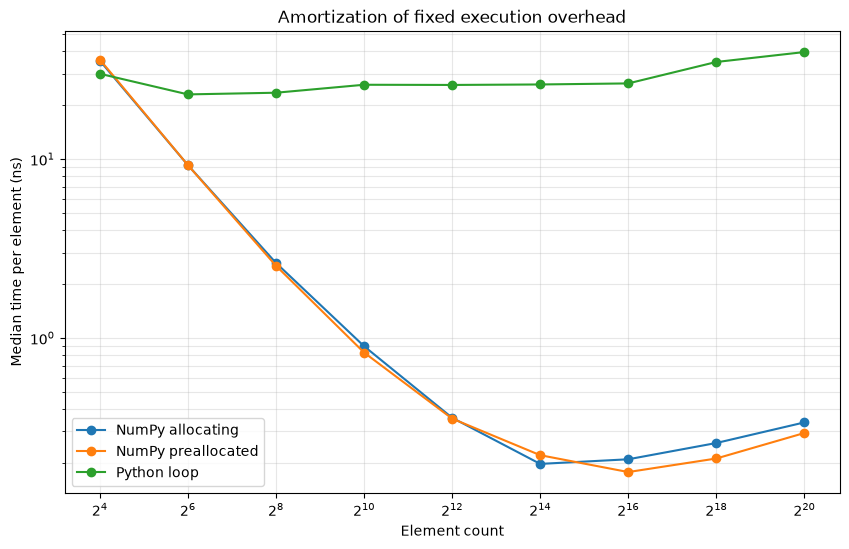

In [ ]:
figure, axis = plt.subplots(figsize=(10, 6))

for implementation, results in vectorization_results.groupby("implementation"):
    axis.plot(
        results["element_count"],
        results["nanoseconds_per_element"],
        marker="o",
        label=implementation,
    )

axis.set_xscale("log", base=2)
axis.set_yscale("log")
axis.set_xlabel("Element count")
axis.set_ylabel("Median time per element (ns)")
axis.set_title("Amortization of fixed execution overhead")
axis.grid(True, which="both", alpha=0.3)
axis.legend()

plt.show()

In [ ]:
import ctypes
import hashlib
import shutil
import subprocess
import textwrap
from pathlib import Path


C_SOURCE = r"""
#include <stddef.h>

void multiply_add(
    const double *restrict input,
    double *restrict output,
    size_t element_count,
    double scale,
    double offset
) {
    for (size_t index = 0; index < element_count; ++index) {
        output[index] = input[index] * scale + offset;
    }
}
"""

compiler = shutil.which("gcc") or shutil.which("cc") or shutil.which("clang")

if compiler is None:
    raise RuntimeError("No C compiler found")

source_hash = hashlib.sha256(C_SOURCE.encode()).hexdigest()[:12]
build_directory = Path("/tmp/dgx-spark-lab-vectorization")
build_directory.mkdir(parents=True, exist_ok=True)

source_path = build_directory / f"multiply_add_{source_hash}.c"
scalar_library_path = build_directory / f"multiply_add_scalar_{source_hash}.so"
vector_library_path = build_directory / f"multiply_add_vector_{source_hash}.so"

source_path.write_text(textwrap.dedent(C_SOURCE))


def compile_library(
    output_path: Path,
    *,
    vectorization_enabled: bool,
) -> subprocess.CompletedProcess[str]:
    command = [
        compiler,
        "-O3",
        "-std=c11",
        "-shared",
        "-fPIC",
        "-Wall",
        "-Wextra",
    ]

    compiler_name = Path(compiler).resolve().name.lower()

    if not vectorization_enabled:
        if "gcc" in compiler_name:
            command.append("-fno-tree-vectorize")
        elif "clang" in compiler_name:
            command.append("-fno-vectorize")
            command.append("-fno-slp-vectorize")
    else:
        if "gcc" in compiler_name:
            command.extend(
                [
                    "-fopt-info-vec-optimized",
                    "-fopt-info-vec-missed",
                ]
            )
        elif "clang" in compiler_name:
            command.extend(
                [
                    "-Rpass=loop-vectorize",
                    "-Rpass-missed=loop-vectorize",
                ]
            )

    command.extend(
        [
            str(source_path),
            "-o",
            str(output_path),
        ]
    )

    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
        check=False,
    )

    if result.returncode != 0:
        raise RuntimeError(f"Compilation failed:\n{result.stderr}")

    return result


scalar_compile = compile_library(
    scalar_library_path,
    vectorization_enabled=False,
)

vector_compile = compile_library(
    vector_library_path,
    vectorization_enabled=True,
)

print(f"Compiler: {Path(compiler).resolve()}")
print("\nVector compiler diagnostics:")
print(vector_compile.stderr or "(none)")

Compiler: /usr/bin/aarch64-linux-gnu-gcc-13

Vector compiler diagnostics:
/tmp/dgx-spark-lab-vectorization/multiply_add_d8b02f61d38d.c:11:34: optimized: loop vectorized using 16 byte vectors



In [13]:
scalar_library = ctypes.CDLL(str(scalar_library_path))
vector_library = ctypes.CDLL(str(vector_library_path))

NDARRAY_POINTER = ctypes.POINTER(ctypes.c_double)

for library in [scalar_library, vector_library]:
    function = library.multiply_add
    function.argtypes = [
        NDARRAY_POINTER,
        NDARRAY_POINTER,
        ctypes.c_size_t,
        ctypes.c_double,
        ctypes.c_double,
    ]
    function.restype = None


def call_native_multiply_add(
    function,
    input_values: np.ndarray,
    output_values: np.ndarray,
    scale: float,
    offset: float,
) -> np.ndarray:
    function(
        input_values.ctypes.data_as(NDARRAY_POINTER),
        output_values.ctypes.data_as(NDARRAY_POINTER),
        input_values.size,
        scale,
        offset,
    )

    return output_values

In [14]:
native_input = np.linspace(
    0.0,
    1.0,
    10_003,
    dtype=np.float64,
)

scalar_output = np.empty_like(native_input)
vector_output = np.empty_like(native_input)
expected_output = native_input * SCALE + OFFSET

call_native_multiply_add(
    scalar_library.multiply_add,
    native_input,
    scalar_output,
    SCALE,
    OFFSET,
)

call_native_multiply_add(
    vector_library.multiply_add,
    native_input,
    vector_output,
    SCALE,
    OFFSET,
)

np.testing.assert_allclose(
    scalar_output,
    expected_output,
    rtol=1e-14,
    atol=1e-14,
)

np.testing.assert_allclose(
    vector_output,
    expected_output,
    rtol=1e-14,
    atol=1e-14,
)

In [22]:
NATIVE_ELEMENT_COUNTS = [
    256,
    1_024,
    4_096,
    16_384,
    65_536,
    262_144,
    1_048_576,
    4_194_304,
    16_777_216,
]

NATIVE_ITERATIONS = 20
NATIVE_WARMUPS = 5

native_rows = []

for element_count in NATIVE_ELEMENT_COUNTS:
    input_values = np.linspace(
        0.0,
        1.0,
        element_count,
        dtype=np.float64,
    )

    scalar_output = np.empty_like(input_values)
    vector_output = np.empty_like(input_values)

    with pinned_to_cpu(VECTOR_CPU):
        scalar_timing = benchmark_callable(
            call_native_multiply_add,
            scalar_library.multiply_add,
            input_values,
            scalar_output,
            SCALE,
            OFFSET,
            warmup_iterations=NATIVE_WARMUPS,
            iterations=NATIVE_ITERATIONS,
        )

        vector_timing = benchmark_callable(
            call_native_multiply_add,
            vector_library.multiply_add,
            input_values,
            vector_output,
            SCALE,
            OFFSET,
            warmup_iterations=NATIVE_WARMUPS,
            iterations=NATIVE_ITERATIONS,
        )

    for implementation, timing in [
        ("C scalar", scalar_timing),
        ("C auto-vectorized", vector_timing),
    ]:
        native_rows.append(
            {
                "element_count": element_count,
                "data_mib_per_array": element_count * 8 / 1024**2,
                "implementation": implementation,
                "median_ms": timing.median_ns / 1e6,
                "nanoseconds_per_element": (timing.median_ns / element_count),
                "giga_elements_per_second": (element_count / timing.median_ns),
            }
        )

native_results = pd.DataFrame(native_rows)
native_results

,element_count,data_mib_per_array,implementation,median_ms,nanoseconds_per_element,giga_elements_per_second
0,256,0.001953,C scalar,0.002896,11.312500,0.088398
1,256,0.001953,C auto-vectorized,0.003504,13.687500,0.073059
2,1024,0.007812,C scalar,0.003816,3.726562,0.268344
3,1024,0.007812,C auto-vectorized,0.003680,3.593750,0.278261
4,4096,0.031250,C scalar,0.004504,1.099609,0.909414
5,4096,0.031250,C auto-vectorized,0.004048,0.988281,1.011858
6,16384,0.125000,C scalar,0.006920,0.422363,2.367630
7,16384,0.125000,C auto-vectorized,0.004704,0.287109,3.482993
8,65536,0.500000,C scalar,0.019600,0.299072,3.343673
9,65536,0.500000,C auto-vectorized,0.011312,0.172607,5.793494


In [25]:
native_comparison = native_results.pivot(
    index=["element_count", "data_mib_per_array"],
    columns="implementation",
    values="median_ms",
).reset_index()

native_comparison["vector_speedup"] = (
    native_comparison["C scalar"] / native_comparison["C auto-vectorized"]
)

native_comparison

implementation,element_count,data_mib_per_array,C auto-vectorized,C scalar,vector_speedup
0,256,0.001953,0.003504,0.002896,0.826484
1,1024,0.007812,0.003680,0.003816,1.036957
2,4096,0.031250,0.004048,0.004504,1.112648
3,16384,0.125000,0.004704,0.006920,1.471088
4,65536,0.500000,0.011312,0.019600,1.732673
5,262144,2.000000,0.038185,0.070897,1.856683
6,1048576,8.000000,0.168625,0.283081,1.678766
7,4194304,32.000000,1.058204,1.227997,1.160453
8,16777216,128.000000,4.927221,5.181790,1.051666


## Observations

Python was faster for the smallest 16-element input because NumPy’s fixed dispatch overhead exceeded the cost of the short Python loop. NumPy overtook Python by 64 elements and reached speedups above 100× for larger arrays. The Python implementation required roughly 23–40 ns per element, whereas NumPy reached approximately 0.18–0.34 ns per element for larger inputs. Preallocating the output had little effect on small arrays but improved larger-array performance by avoiding repeated output allocation and temporary-array management.

## Explanation

TODO: Separate Python overhead, compiled loops, SIMD, and memory-bandwidth effects.

## Connection to LLMs

Vectorization underpins optimized preprocessing and many tensor operations used around LLM inference.

## Further Exploration

TODO: Inspect operation size, data type, alignment, and thread-count effects.